# GUÍA 3 – PARCIAL 1: TELEDETECCIÓN
## Opción 2: Dataset MASATI – Detección de Barcos
### Reto 2: «Segmentación automática con SAM»


## 0. Configuración del entorno

In [ ]:
# Instalación de SAM y descarga del checkpoint ViT-B (aprox 375 MB)
!pip -q install git+https://github.com/facebookresearch/segment-anything.git
!mkdir -p /content/checkpoints
!wget -q -nc -P /content/checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
!nvidia-smi --query-gpu=name,memory.total --format=csv || echo "Sin GPU: activen una GPU en el entorno de ejecución"

  Preparing metadata (setup.py) ... done
name, memory.total [MiB]
Tesla T4, 15360 MiB


In [ ]:
import os, sys, math, random, shutil, zipfile, time, warnings
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')

# ================== CONFIGURACIÓN (ajusten aquí) ==================
CARPETA_DRIVE = os.environ.get('MASATI_DRIVE', '/content/drive/MyDrive/Vision')
RUTA_ZIP      = os.environ.get('MASATI_ZIP', f'{CARPETA_DRIVE}/MASATI-v2.zip')
DATA_ROOT     = os.environ.get('MASATI_DIR', '/content/MASATI-v2')   # aquí se descomprime el zip (local, rápido)
SALIDA        = Path(os.environ.get('MASATI_OUT', f'{CARPETA_DRIVE}/reto2_resultados'))  # en Drive: no se pierde
N_BARCOS_RECORTE = 20
LIMITE_IMAGENES_POR_ESCENA = None      # p. ej. 30 para una prueba rápida; None = todo el dataset
REINICIAR_SAM = False                  # True = ignorar el avance guardado y recalcular todo
SEED = 42
# ==================================================================
random.seed(SEED); np.random.seed(SEED)

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

if not Path(DATA_ROOT).exists() and Path(RUTA_ZIP).exists():
    print('Descomprimiendo', RUTA_ZIP, '->', DATA_ROOT)
    with zipfile.ZipFile(RUTA_ZIP) as z:
        z.extractall(DATA_ROOT)
assert Path(DATA_ROOT).exists(), f'No encuentro el dataset en {DATA_ROOT}. Revisen RUTA_ZIP.'
SALIDA.mkdir(parents=True, exist_ok=True)
DIR_SAM = SALIDA / 'etiquetas_SAM'          # aquí quedan las carpetas *_labels_SAM
FIGURAS = SALIDA / 'figuras'; FIGURAS.mkdir(exist_ok=True)
def guardar_fig(nombre): plt.savefig(FIGURAS / f'{nombre}.png', dpi=130, bbox_inches='tight')

# Escenas con barcos: (carpeta de imágenes, carpeta de etiquetas). Se buscan en cualquier nivel del zip.
SCENES = {'ship': ('ship', 'ship_labels'), 'coast_ship': ('coast_ship', 'coast_ship_labels'),
          'multi': ('multi', 'multi_labels'), 'detail': ('detail', 'detail_labels')}

def buscar_carpeta(raiz, nombre):
    raiz = Path(raiz)
    if (raiz / nombre).is_dir(): return raiz / nombre
    return next((p for p in raiz.rglob(nombre) if p.is_dir()), None)

CARPETAS = {}
for escena, (img_dir, lbl_dir) in SCENES.items():
    d_img, d_lbl = buscar_carpeta(DATA_ROOT, img_dir), buscar_carpeta(DATA_ROOT, lbl_dir)
    if d_img and d_lbl: CARPETAS[escena] = (d_img, d_lbl)
    else: print(f'«{escena}» se omite: imágenes={d_img}, etiquetas={d_lbl}')
print('Escenas con etiquetas:', list(CARPETAS))
print('Resultados en:', SALIDA)

Mounted at /content/drive
Descomprimiendo /content/drive/MyDrive/Vision/MASATI-v2.zip -> /content/MASATI-v2
«detail» se omite: imágenes=/content/MASATI-v2/MASATI-v2/detail, etiquetas=None
Escenas con etiquetas: ['ship', 'coast_ship', 'multi']
Resultados en: /content/drive/MyDrive/Vision/reto2_resultados


In [ ]:
def leer_xml(ruta_xml):
    # Devuelve {índice_del_objeto: (xmin, ymin, xmax, ymax)}; omite objetos sin <bndbox>
    raiz = ET.parse(ruta_xml).getroot()
    cajas = {}
    for i, obj in enumerate(raiz.iter('object')):
        bb = obj.find('bndbox')
        if bb is None: continue
        x1, y1, x2, y2 = (int(round(float(bb.findtext(k)))) for k in ('xmin', 'ymin', 'xmax', 'ymax'))
        cajas[i] = (min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2))
    return cajas

def buscar_imagen(d_img, base):
    # Se busca por el nombre del XML: el campo <filename> de algunos XML de MASATI no corresponde a la imagen
    for ext in ('.png', '.jpg', '.jpeg', '.tif', '.bmp'):
        if (Path(d_img) / (base + ext)).exists(): return Path(d_img) / (base + ext)
    return None

def leer_imagen(ruta):
    return np.array(Image.open(ruta).convert('RGB'))

filas, sin_imagen = [], 0
for escena, (d_img, d_lbl) in CARPETAS.items():
    for xml in sorted(Path(d_lbl).glob('*.xml')):
        ruta_img = buscar_imagen(d_img, xml.stem)
        if ruta_img is None: sin_imagen += 1; continue
        for idx, (x1, y1, x2, y2) in leer_xml(xml).items():
            filas.append(dict(escena=escena, xml=str(xml), carpeta_xml=d_lbl.name, imagen=str(ruta_img),
                              obj_idx=idx, xmin=x1, ymin=y1, xmax=x2, ymax=y2))
df_cajas = pd.DataFrame(filas)
df_cajas['lado_eq'] = np.sqrt((df_cajas.xmax - df_cajas.xmin + 1) * (df_cajas.ymax - df_cajas.ymin + 1))
ESCENAS = list(CARPETAS)
print(f'{len(df_cajas):,} barcos en {df_cajas.imagen.nunique():,} imágenes · XML sin imagen: {sin_imagen}')
display(df_cajas.groupby('escena').agg(imagenes=('imagen', 'nunique'), barcos=('obj_idx', 'size')).reindex(ESCENAS))

4,054 barcos en 2,368 imágenes · XML sin imagen: 0


,imagenes,barcos
escena,,
ship,1027,1027
coast_ship,1037,1061
multi,304,1966


## 2.1. ¿Qué es SAM?

**Segment Anything Model (SAM)** es un modelo de Meta AI (*Kirillov et al., 2023, "Segment Anything", ICCV*). Es un modelo de segmentación promptable: recibe una imagen y una indicación uno o varios puntos, una caja o una máscara aproximada y devuelve la máscara del objeto señalado. No hay que reentrenarlo para cada tipo de objeto: se usa preentrenado.

Su arquitectura tiene tres partes:

1. **Codificador de imagen (*image encoder*)**: un Vision Transformer (ViT) que se ejecuta una sola vez por imagen. La imagen se redimensiona a 1024 px en su lado mayor y se convierte en un mapa de características de 64 × 64.
2. **Codificador de prompts (*prompt encoder*)**: convierte los puntos o la caja en vectores.
3. **Decodificador de máscaras (*mask decoder*)**: liviano; combina el mapa de la imagen con el prompt y produce la máscara junto con un puntaje de calidad estimado, predicted IoU el tambien conocido como score. Como es rápido, se pueden pedir muchas máscaras sobre la misma imagen sin volver a codificarla.

Se entrenó con SA-1B: 11 millones de imágenes y más de 1 000 millones de máscaras. Usamos el checkpoint ViT-B (Alrededor de 91 M de parámetros), el más liviano de los tres (B, L, H).

> SAM 2 (2024) añade memoria para seguir objetos en video (memory attention, memory bank). Aquí trabajamos con imágenes fijas y usamos el **SAM original**, que no tiene esos módulos.

**Dos formas de usarlo en este reto:**

- **Automático** (`SamAutomaticMaskGenerator`): coloca una cuadrícula de puntos sobre la imagen y segmenta todo lo que encuentra, sin decirle qué buscamos.
- **Con caja** (`SamPredictor` + `box`): le damos la caja original del XML y devuelve la máscara del objeto que hay dentro. La caja mínima que encierra esa máscara es la nueva etiqueta SAM.



## Carga de SAM y funciones de apoyo

In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

DISPOSITIVO = 'cuda' if torch.cuda.is_available() else 'cpu'
sam = sam_model_registry['vit_b'](checkpoint='/content/checkpoints/sam_vit_b_01ec64.pth').to(DISPOSITIVO).eval()
predictor = SamPredictor(sam)
print('SAM ViT-B cargado en', DISPOSITIVO)
if DISPOSITIVO == 'cpu': print('ATENCIÓN: sin GPU la sección 4 tardará horas. Activen una GPU T4.')

SAM ViT-B cargado en cuda


La máscara que devuelve SAM se post-procesa antes de convertirla en caja:

1. **Vecindad.** La máscara se limita a una ventana alrededor de la caja original (la caja más un 50 % de su tamaño por cada lado, mínimo 8 px). Sin esto, cuando SAM confunde el barco con la costa, un muelle o un barco vecino, la "caja" crece a media imagen. La fracción de máscara que quedó fuera de esa ventana se guarda como **`fuga`**: es un indicador de que SAM se fue hacia otro objeto.
2. **Componente principal.** Si la máscara queda en varios pedazos, se conserva el que más se superpone con la caja original (descarta espuma o reflejos sueltos).
3. **Respaldo.** Si la máscara queda vacía o con menos de 4 píxeles, se conserva la caja original y se marca el caso en la columna `estado`.

Las coordenadas del XML (PASCAL VOC) indican el **primer y el último píxel** del barco, así que la nueva caja se escribe con la misma convención: `xmax` es la última columna de la máscara, sin sumar 1.

In [ ]:
COLOR_ORIG = '#00e676'   # verde: etiqueta original (humana)
COLOR_SAM  = '#ff1744'   # rojo : etiqueta SAM
MARGEN_VECINDAD, MIN_PIXELES_MASCARA = 0.5, 4

def rect(ax, caja, color, lw=1.6, ls='-'):
    x1, y1, x2, y2 = caja
    ax.add_patch(patches.Rectangle((x1 - .5, y1 - .5), x2 - x1 + 1, y2 - y1 + 1,
                                   fill=False, edgecolor=color, linewidth=lw, linestyle=ls))

def recorte(img, caja, margen=0.8, minimo=24):
    # Ventana cuadrada alrededor de una caja (para hacer zoom); devuelve (sub-imagen, x0, y0)
    x1, y1, x2, y2 = caja
    lado = max(minimo, int(max(x2 - x1 + 1, y2 - y1 + 1) * (1 + 2 * margen)))
    H, W = img.shape[:2]
    x0 = int(np.clip((x1 + x2) / 2 - lado / 2, 0, max(0, W - lado)))
    y0 = int(np.clip((y1 + y2) / 2 - lado / 2, 0, max(0, H - lado)))
    return img[y0:y0 + lado, x0:x0 + lado], x0, y0

def vecindad(caja, W, H, margen=MARGEN_VECINDAD, minimo=8):
    x1, y1, x2, y2 = caja
    mx = max(minimo, round(margen * (x2 - x1 + 1))); my = max(minimo, round(margen * (y2 - y1 + 1)))
    return max(0, x1 - mx), max(0, y1 - my), min(W - 1, x2 + mx), min(H - 1, y2 + my)

def componente_principal(m, caja):
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m.astype(np.uint8), connectivity=8)
    if n <= 2: return m
    x1, y1, x2, y2 = caja
    cuenta = np.bincount(lab[max(0, y1):y2 + 1, max(0, x1):x2 + 1].ravel(), minlength=n); cuenta[0] = 0
    k = int(cuenta.argmax()) if cuenta.max() > 0 else 1 + int(stats[1:, cv2.CC_STAT_AREA].argmax())
    return lab == k

def segmentar_con_caja(caja):
    # Requiere predictor.set_image(img) antes. SAM recibe la caja con borde exclusivo (+1).
    x1, y1, x2, y2 = caja
    masks, scores, _ = predictor.predict(box=np.array([x1, y1, x2 + 1, y2 + 1], dtype=float), multimask_output=False)
    return masks[0].astype(bool), float(scores[0])

def refinar_caja(mascara, caja, W, H):
    vx1, vy1, vx2, vy2 = vecindad(caja, W, H)
    m = np.zeros_like(mascara); m[vy1:vy2 + 1, vx1:vx2 + 1] = mascara[vy1:vy2 + 1, vx1:vx2 + 1]
    total = int(mascara.sum()); fuga = 1 - m.sum() / total if total else 0.0
    if m.any(): m = componente_principal(m, caja)
    area = int(m.sum())
    if area == 0:                    return dict(estado='sin_mascara', caja=caja, area_mascara=0, fuga=fuga, mascara=m)
    if area < MIN_PIXELES_MASCARA:   return dict(estado='mascara_diminuta', caja=caja, area_mascara=area, fuga=fuga, mascara=m)
    ys, xs = np.where(m)
    return dict(estado='sam', caja=(int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                area_mascara=area, fuga=fuga, mascara=m)

def superponer(img, mascara, color=(255, 23, 68), alpha=.5):
    out = img.astype(float).copy(); out[mascara] = (1 - alpha) * out[mascara] + alpha * np.array(color)
    return out.astype(np.uint8)

def superponer_auto(img, anns, alpha=.55, semilla=0):
    out = img.astype(float).copy(); rng = np.random.default_rng(semilla)
    for a in sorted(anns, key=lambda d: -d['area']):
        s = a['segmentation']; out[s] = (1 - alpha) * out[s] + alpha * rng.integers(40, 256, 3)
    return out.astype(np.uint8)

def iou_mascaras(a, b):
    u = np.logical_or(a, b).sum()
    return np.logical_and(a, b).sum() / u if u else 0.0

## 2.2. SAM sobre un recorte con por lo menos 20 barcos

Se toma la imagen con más barcos etiquetados y se busca el **recuadro más pequeño que encierra al menos 20 barcos**: para cada barco se toman sus 19 vecinos más cercanos y se calcula la caja que los contiene; se elige la de menor área. Sobre ese recorte se aplica SAM de dos formas:

- **(b) Automático:** sin ninguna indicación.
- **(c) Con caja:** una máscara por cada barco, usando su caja original como prompt.

Para saber si el modo automático "encontró" un barco, se compara cada máscara automática con la máscara obtenida con la caja de ese barco (IoU de máscaras > 0,5). Se comparan máscaras y no cajas porque la caja humana suele ser holgada: una máscara bien ajustada al barco tendría un IoU bajo contra ella aunque sea correcta.


***nota*** IoU (Intersection over Union), porcentaje de area que coincide de la predicción a la anotación humana

Imágenes con ≥ 20 barcos: 14
Imagen: y0003.png (82 barcos) · recorte (x0,y0,x1,y1) = (125, 40, 218, 141), 94×102 px · barcos completos dentro: 23


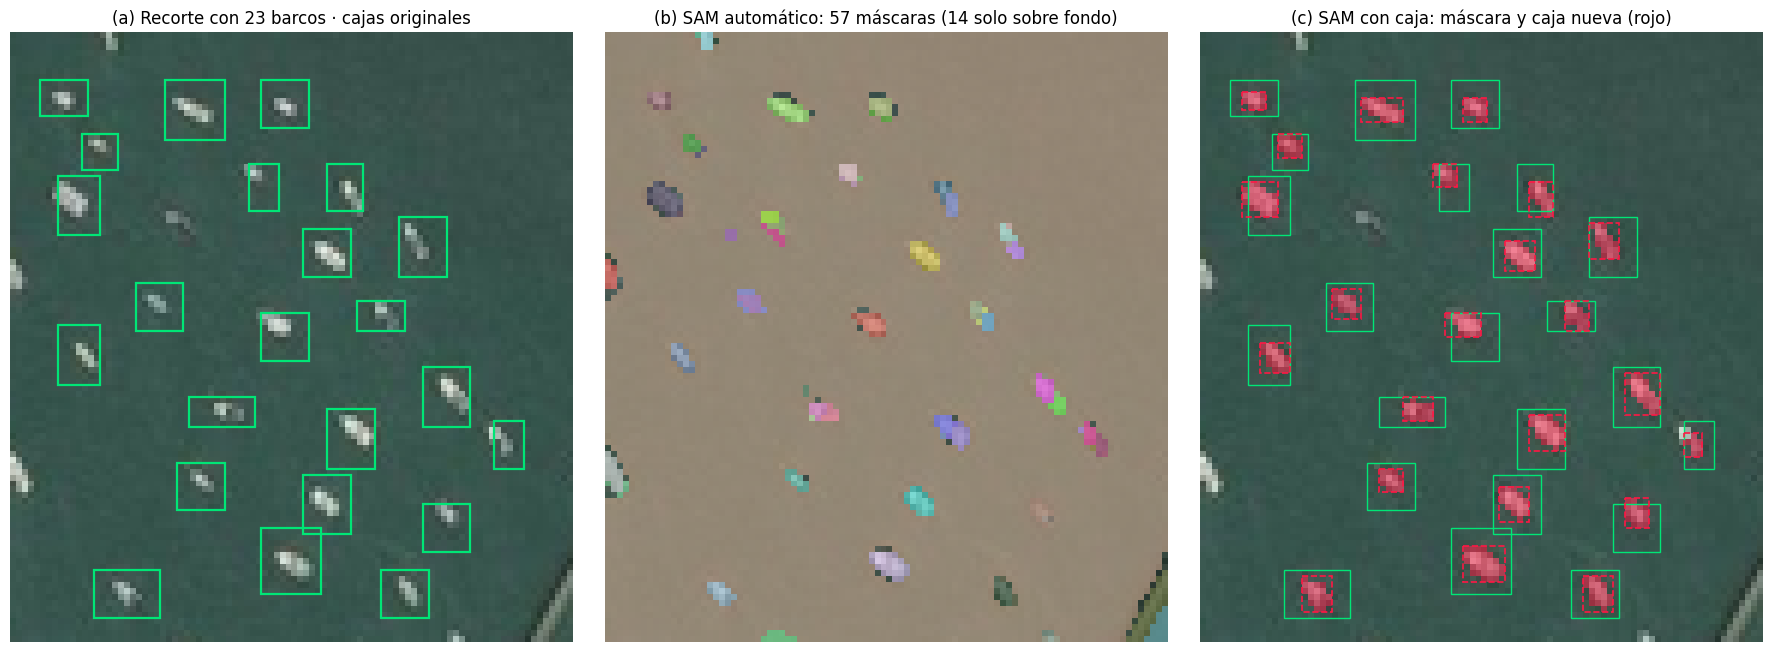

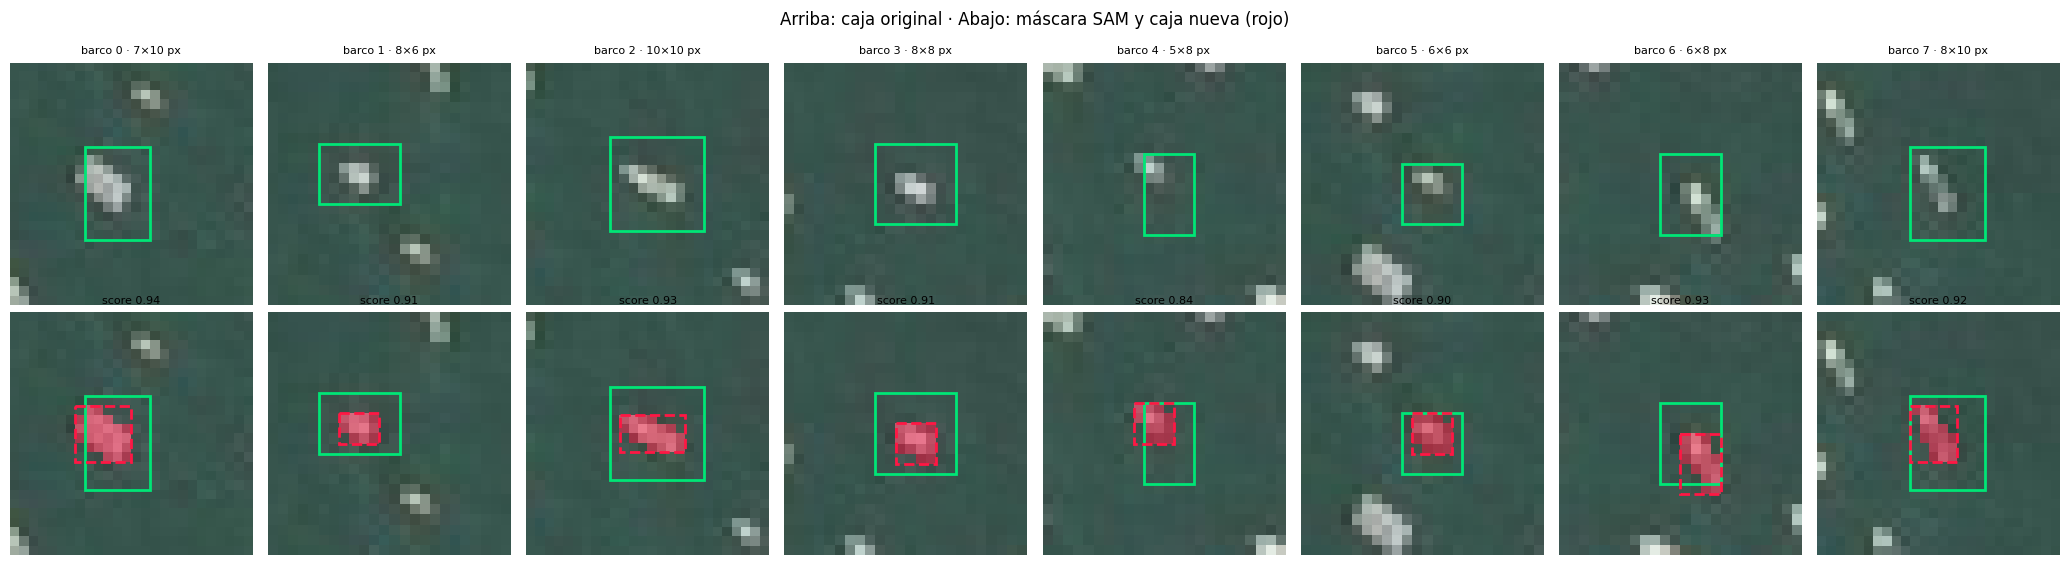

,barco,tam_orig,score_sam,estado,iou_mejor_mascara_auto
0,0,7×10,0.943,sam,0.923
1,1,8×6,0.908,sam,1.000
2,2,10×10,0.932,sam,1.000
3,3,8×8,0.914,sam,1.000
4,4,5×8,0.836,sam,0.714
5,5,6×6,0.899,sam,0.714
6,6,6×8,0.929,sam,0.941
7,7,8×10,0.925,sam,0.778
8,8,8×8,0.939,sam,1.000
9,9,8×5,0.920,sam,0.933


In [ ]:
def recorte_denso(cajas, W, H, n_min, margen=8):
    # Recuadro de menor área que contiene al menos n_min cajas completas
    cajas = np.asarray(cajas); n = min(n_min, len(cajas))
    centros = np.c_[(cajas[:, 0] + cajas[:, 2]) / 2, (cajas[:, 1] + cajas[:, 3]) / 2]
    mejor = None
    for i in range(len(cajas)):
        sub = cajas[np.argsort(np.linalg.norm(centros - centros[i], axis=1))[:n]]
        r = (max(0, sub[:, 0].min() - margen), max(0, sub[:, 1].min() - margen),
             min(W - 1, sub[:, 2].max() + margen), min(H - 1, sub[:, 3].max() + margen))
        area = (r[2] - r[0] + 1) * (r[3] - r[1] + 1)
        if mejor is None or area < mejor[0]: mejor = (area, r)
    x0, y0, x1, y1 = (int(v) for v in mejor[1])
    dentro = [k for k, b in enumerate(cajas) if b[0] >= x0 and b[1] >= y0 and b[2] <= x1 and b[3] <= y1]
    return (x0, y0, x1, y1), dentro

conteo = df_cajas.groupby('imagen').size().sort_values(ascending=False)
print(f'Imágenes con ≥ {N_BARCOS_RECORTE} barcos: {(conteo >= N_BARCOS_RECORTE).sum()}')
if conteo.iloc[0] < N_BARCOS_RECORTE:
    print(f'ATENCIÓN: ninguna imagen llega a {N_BARCOS_RECORTE} barcos; se usa la que más tiene ({conteo.iloc[0]}).')
RUTA_RECORTE = conteo.index[0]
g = df_cajas[df_cajas.imagen == RUTA_RECORTE].reset_index(drop=True)
img_r = leer_imagen(RUTA_RECORTE); H, W = img_r.shape[:2]
cajas_img = g[['xmin', 'ymin', 'xmax', 'ymax']].to_numpy()
(cx0, cy0, cx1, cy1), dentro = recorte_denso(cajas_img, W, H, N_BARCOS_RECORTE)
crop = img_r[cy0:cy1 + 1, cx0:cx1 + 1].copy()
cajas_crop = [tuple(int(v) for v in (b[0] - cx0, b[1] - cy0, b[2] - cx0, b[3] - cy0)) for b in cajas_img[dentro]]
print(f'Imagen: {Path(RUTA_RECORTE).name} ({len(g)} barcos) · recorte (x0,y0,x1,y1) = {(cx0, cy0, cx1, cy1)}, '
      f'{crop.shape[1]}×{crop.shape[0]} px · barcos completos dentro: {len(cajas_crop)}')

# (b) automático
generador_auto = SamAutomaticMaskGenerator(sam, points_per_side=32, pred_iou_thresh=0.80,
                                           stability_score_thresh=0.85, min_mask_region_area=0)
anns = generador_auto.generate(crop)

# (c) con caja, barco por barco
predictor.set_image(crop)
res_crop = []
for k, caja in enumerate(cajas_crop):
    m, score = segmentar_con_caja(caja)
    ref = refinar_caja(m, caja, crop.shape[1], crop.shape[0])
    mejor_auto = max((iou_mascaras(a['segmentation'], ref['mascara']) for a in anns), default=0.0)
    res_crop.append(dict(barco=k, tam_orig=f'{caja[2] - caja[0] + 1}×{caja[3] - caja[1] + 1}', score_sam=score,
                         estado=ref['estado'], iou_mejor_mascara_auto=mejor_auto, _ref=ref, _caja=caja))
union_barcos = np.zeros(crop.shape[:2], bool)
for c in cajas_crop: union_barcos[c[1]:c[3] + 1, c[0]:c[2] + 1] = True
auto_fondo = sum(1 for a in anns if not (a['segmentation'] & union_barcos).any())

fig, axs = plt.subplots(1, 3, figsize=(18, 6.4))
axs[0].imshow(crop, interpolation='nearest')
for c in cajas_crop: rect(axs[0], c, COLOR_ORIG)
axs[0].set_title(f'(a) Recorte con {len(cajas_crop)} barcos · cajas originales')
axs[1].imshow(superponer_auto(crop, anns), interpolation='nearest')
axs[1].set_title(f'(b) SAM automático: {len(anns)} máscaras ({auto_fondo} solo sobre fondo)')
mascara_total = np.zeros(crop.shape[:2], bool)
for r in res_crop: mascara_total |= r['_ref']['mascara']
axs[2].imshow(superponer(crop, mascara_total), interpolation='nearest')
for r in res_crop:
    rect(axs[2], r['_caja'], COLOR_ORIG, lw=1); rect(axs[2], r['_ref']['caja'], COLOR_SAM, lw=1.2, ls='--')
axs[2].set_title('(c) SAM con caja: máscara y caja nueva (rojo)')
for a in axs: a.axis('off')
plt.tight_layout(); guardar_fig('reto2_recorte_20_barcos'); plt.show()

# Acercamiento a 8 barcos del recorte
n_zoom = min(8, len(res_crop))
fig, axs = plt.subplots(2, n_zoom, figsize=(2.6 * n_zoom, 5.6), squeeze=False)
for j, r in enumerate(res_crop[:n_zoom]):
    c, x0, y0 = recorte(crop, r['_caja'])
    loc = lambda b: (b[0] - x0, b[1] - y0, b[2] - x0, b[3] - y0)
    axs[0, j].imshow(c, interpolation='nearest'); rect(axs[0, j], loc(r['_caja']), COLOR_ORIG, lw=2)
    axs[0, j].set_title(f"barco {r['barco']} · {r['tam_orig']} px", fontsize=8)
    m = r['_ref']['mascara'][y0:y0 + c.shape[0], x0:x0 + c.shape[1]]
    axs[1, j].imshow(superponer(c, m), interpolation='nearest')
    rect(axs[1, j], loc(r['_caja']), COLOR_ORIG, lw=2); rect(axs[1, j], loc(r['_ref']['caja']), COLOR_SAM, lw=2, ls='--')
    axs[1, j].set_title(f"score {r['score_sam']:.2f}", fontsize=8)
    for a in axs[:, j]: a.axis('off')
plt.suptitle('Arriba: caja original · Abajo: máscara SAM y caja nueva (rojo)', y=1.0)
plt.tight_layout(); guardar_fig('reto2_recorte_zoom'); plt.show()

tabla_crop = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in res_crop])
display(tabla_crop.round(3))

La imagen seleccionada en este ejemplo es la y003.png en la carpeta multi.

SAM en modo libre etiqueta múltiples objetos de la escena con máscaras discretas, incluso dividiendo un barco en varias partes. En cambio, cuando se le da la caja del XML, la usa como guía de interés y ajusta la segmentación: puede expandirse más allá de la caja si el objeto lo requiere o reducirse si es más pequeño, generando una máscara más precisa del barco.

In [ ]:
t = tabla_crop; encontrados = int((t.iou_mejor_mascara_auto > 0.5).sum())
display(Markdown(f'''
**Resultados del recorte ({len(t)} barcos):**

- **Automático:** SAM generó **{len(anns)} máscaras**, de las cuales **{auto_fondo}** caen solo sobre el fondo (agua, costa, espuma), sin tocar ningún barco. **{encontrados} de {len(t)}** barcos ({100 * encontrados / len(t):.0f} %) coinciden con alguna máscara automática (IoU de máscara > 0,5). ''' + ('''Sin un prompt, SAM segmenta "todo lo que parece un objeto", pero no sabe que lo que nos interesa son los barcos: varios barcos quedan sin máscara propia, unidos a otros o partidos en pedazos.''' if encontrados < len(t) else '''Aun así, sin un prompt SAM no distingue cuáles de esas máscaras son barcos: habría que decidirlo después.''') + f'''
- **Con caja:** el puntaje de calidad estimado por SAM fue en promedio **{t.score_sam.mean():.2f}** (mín. {t.score_sam.min():.2f}, máx. {t.score_sam.max():.2f}); en {int((t.estado != "sam").sum())} barcos la máscara quedó vacía o diminuta y se conservó la caja original.
- Por eso, para refinar las etiquetas del dataset se usa el **modo con caja**: la caja original le dice a SAM *qué* objeto segmentar.
'''))


**Resultados del recorte (23 barcos):**

- **Automático:** SAM generó **57 máscaras**, de las cuales **14** caen solo sobre el fondo (agua, costa, espuma), sin tocar ningún barco. **23 de 23** barcos (100 %) coinciden con alguna máscara automática (IoU de máscara > 0,5). Aun así, sin un prompt SAM no distingue cuáles de esas máscaras son barcos: habría que decidirlo después.
- **Con caja:** el puntaje de calidad estimado por SAM fue en promedio **0.91** (mín. 0.84, máx. 0.94); en 0 barcos la máscara quedó vacía o diminuta y se conservó la caja original.
- Por eso, para refinar las etiquetas del dataset se usa el **modo con caja**: la caja original le dice a SAM *qué* objeto segmentar.


## 4. SAM sobre la imagen completa, barco por barco

Para cada imagen se calcula **una sola vez** el mapa de características (`set_image`) y luego se pide a SAM una máscara por cada caja del XML. El avance se guarda en Drive cada 100 imágenes: si Colab se desconecta, al volver a ejecutar la celda continúa donde iba. Con GPU T4 el dataset completo toma unos minutos.

In [ ]:
RUTA_CSV = SALIDA / 'resultados_sam.csv'
if REINICIAR_SAM and RUTA_CSV.exists(): RUTA_CSV.unlink()

imagenes = []
for e in ESCENAS:
    rutas = sorted(df_cajas.loc[df_cajas.escena == e, 'imagen'].unique())
    if LIMITE_IMAGENES_POR_ESCENA: rutas = random.Random(SEED).sample(rutas, min(LIMITE_IMAGENES_POR_ESCENA, len(rutas)))
    imagenes += rutas

previos = pd.read_csv(RUTA_CSV) if RUTA_CSV.exists() else pd.DataFrame()
hechas = set(previos.imagen) if len(previos) else set()
pendientes = [r for r in imagenes if r not in hechas]
print(f'Imágenes: {len(imagenes):,} · ya procesadas: {len(hechas):,} · pendientes: {len(pendientes):,}')

grupos = {r: g for r, g in df_cajas.groupby('imagen')}
nuevos, t0 = [], time.time()
def volcar():
    global previos, nuevos
    if nuevos:
        previos = pd.concat([previos, pd.DataFrame(nuevos)], ignore_index=True); nuevos = []
        previos.to_csv(RUTA_CSV, index=False)

for k, ruta in enumerate(tqdm(pendientes, desc='SAM por imagen')):
    img = leer_imagen(ruta); H, W = img.shape[:2]
    predictor.set_image(img)
    for _, r in grupos[ruta].iterrows():
        caja = (int(np.clip(r.xmin, 0, W - 1)), int(np.clip(r.ymin, 0, H - 1)),
                int(np.clip(r.xmax, 0, W - 1)), int(np.clip(r.ymax, 0, H - 1)))
        m, score = segmentar_con_caja(caja)
        ref = refinar_caja(m, caja, W, H)
        nuevos.append(dict(xml=r.xml, obj_idx=int(r.obj_idx), imagen=ruta, estado=ref['estado'], score_sam=score,
                           area_mascara=ref['area_mascara'], fuga=ref['fuga'],
                           sam_xmin=ref['caja'][0], sam_ymin=ref['caja'][1],
                           sam_xmax=ref['caja'][2], sam_ymax=ref['caja'][3]))
    if (k + 1) % 100 == 0: volcar()
volcar()
print(f'Listo en {time.time() - t0:.0f} s')

df_sam = df_cajas.merge(previos.drop(columns='imagen'), on=['xml', 'obj_idx'], how='inner')
print(f'Barcos refinados: {len(df_sam):,}')
display(pd.crosstab(df_sam.escena, df_sam.estado, margins=True, margins_name='TOTAL').reindex(ESCENAS + ['TOTAL']))

Imágenes: 2,368 · ya procesadas: 2,368 · pendientes: 0


SAM por imagen: 0it [00:00, ?it/s]

Listo en 0 s
Barcos refinados: 4,054


estado,sam,TOTAL
escena,,
ship,1027,1027
coast_ship,1061,1061
multi,1966,1966
TOTAL,4054,4054


### Ejemplos sobre la imagen completa

Una imagen al azar por escena, con las máscaras de SAM, la caja original (verde) y la caja nueva (rojo discontinuo), y un acercamiento a dos de sus barcos. La comparación detallada entre ambos conjuntos de cajas se hace en el Reto 3.

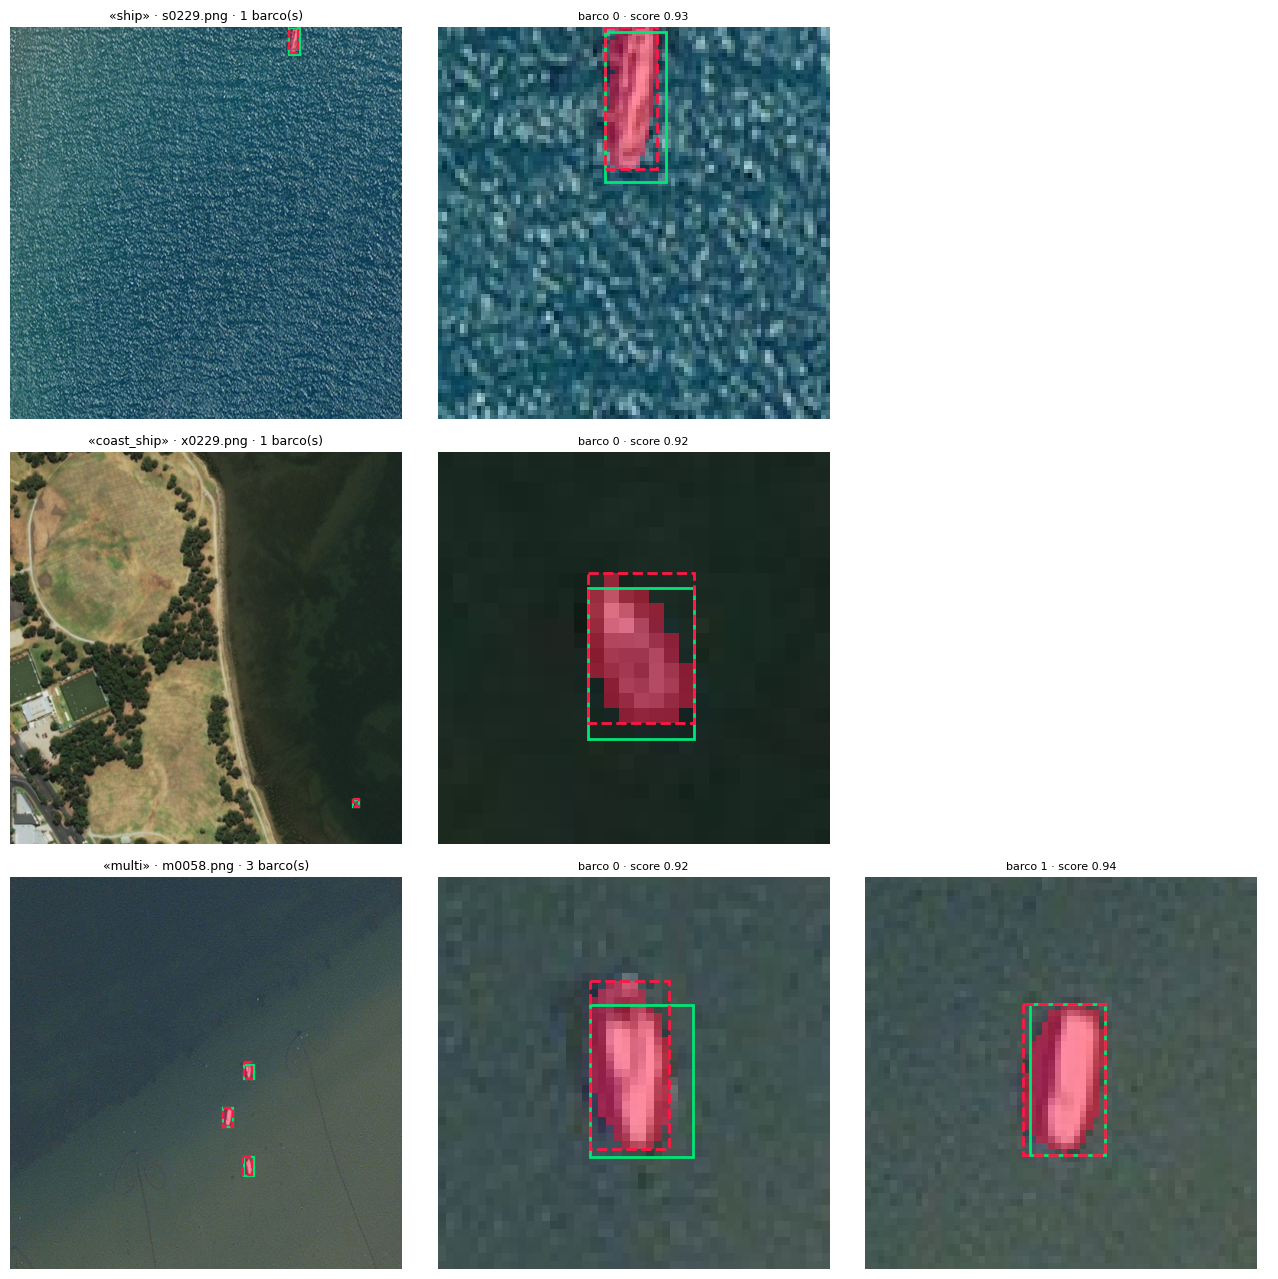

In [ ]:
fig, axs = plt.subplots(len(ESCENAS), 3, figsize=(13, 4.3 * len(ESCENAS)), squeeze=False)
for fila, e in zip(axs, ESCENAS):
    ruta = random.Random(SEED).choice(sorted(df_sam.loc[df_sam.escena == e, 'imagen'].unique()))
    img = leer_imagen(ruta); H, W = img.shape[:2]; g = df_sam[df_sam.imagen == ruta]
    predictor.set_image(img)
    total = np.zeros((H, W), bool)
    for _, r in g.iterrows():
        caja = (int(r.xmin), int(r.ymin), int(r.xmax), int(r.ymax))
        total |= refinar_caja(segmentar_con_caja(caja)[0], caja, W, H)['mascara']
    vista = superponer(img, total)
    fila[0].imshow(vista)
    for _, r in g.iterrows():
        rect(fila[0], (r.xmin, r.ymin, r.xmax, r.ymax), COLOR_ORIG); rect(fila[0], (r.sam_xmin, r.sam_ymin, r.sam_xmax, r.sam_ymax), COLOR_SAM, ls='--')
    fila[0].set_title(f'«{e}» · {Path(ruta).name} · {len(g)} barco(s)', fontsize=9)
    for j, ax in enumerate(fila[1:]):
        if j < len(g):
            r = g.iloc[j]; c, x0, y0 = recorte(vista, (r.xmin, r.ymin, r.xmax, r.ymax))
            ax.imshow(c, interpolation='nearest')
            rect(ax, (r.xmin - x0, r.ymin - y0, r.xmax - x0, r.ymax - y0), COLOR_ORIG, lw=2)
            rect(ax, (r.sam_xmin - x0, r.sam_ymin - y0, r.sam_xmax - x0, r.sam_ymax - y0), COLOR_SAM, lw=2, ls='--')
            ax.set_title(f'barco {r.obj_idx} · score {r.score_sam:.2f}', fontsize=8)
        ax.axis('off')
    fila[0].axis('off')
plt.tight_layout(); guardar_fig('reto2_ejemplos_imagen_completa'); plt.show()

## 5. Nuevo dataset con etiquetas `_SAM`

Cada XML original se copia a una subcarpeta con sufijo `_SAM` (por ejemplo `ship_labels` → `ship_labels_SAM`) dentro de `etiquetas_SAM/` en Drive, cambiando **solo** las coordenadas de `<bndbox>`. El resto del XML queda idéntico, así que cualquier lector PASCAL VOC lo puede usar. Al final se vuelven a leer los XML escritos para verificar que contienen las cajas calculadas.

In [ ]:
nuevas_por_xml = {}
for _, r in df_sam.iterrows():
    nuevas_por_xml.setdefault((r.xml, r.carpeta_xml), {})[int(r.obj_idx)] = (int(r.sam_xmin), int(r.sam_ymin), int(r.sam_xmax), int(r.sam_ymax))

def destino(xml, carpeta): return DIR_SAM / f'{carpeta}_SAM' / Path(xml).name

for (xml, carpeta), nuevas in tqdm(nuevas_por_xml.items(), desc='Escribiendo XML _SAM'):
    arbol = ET.parse(xml)
    for i, obj in enumerate(arbol.getroot().iter('object')):
        bb = obj.find('bndbox')
        if i in nuevas and bb is not None:
            for tag, v in zip(('xmin', 'ymin', 'xmax', 'ymax'), nuevas[i]):
                if bb.find(tag) is not None: bb.find(tag).text = str(v)
    d = destino(xml, carpeta); d.parent.mkdir(parents=True, exist_ok=True)
    arbol.write(d, encoding='utf-8')

errores = sum(leer_xml(destino(xml, carpeta)).get(i) != caja
              for (xml, carpeta), nuevas in nuevas_por_xml.items() for i, caja in nuevas.items())
print(f'XML escritos: {len(nuevas_por_xml):,} en {DIR_SAM}')
print('Carpetas:', sorted(p.name for p in DIR_SAM.iterdir() if p.is_dir()))
print('Verificación (releer y comparar):', 'OK' if errores == 0 else f'{errores} diferencias')

shutil.make_archive(str(SALIDA / 'etiquetas_SAM'), 'zip', DIR_SAM)
df_sam.to_csv(SALIDA / 'cajas_original_vs_sam.csv', index=False)
print('Zip del nuevo dataset:', SALIDA / 'etiquetas_SAM.zip')

Escribiendo XML _SAM:   0%|          | 0/2368 [00:00<?, ?it/s]

XML escritos: 2,368 en /content/drive/MyDrive/Vision/reto2_resultados/etiquetas_SAM
Carpetas: ['coast_ship_labels_SAM', 'multi_labels_SAM', 'ship_labels_SAM']
Verificación (releer y comparar): OK
Zip del nuevo dataset: /content/drive/MyDrive/Vision/reto2_resultados/etiquetas_SAM.zip


## 6. Conclusiones y análisis

**Cuantitativas** (se escriben solas con los números de la ejecución):

In [ ]:
pct = lambda s: 100 * s.mean()
porc_estado = df_sam.estado.value_counts(normalize=True) * 100
corr = np.corrcoef(np.log(df_sam.lado_eq), df_sam.score_sam)[0, 1]
por_tam = df_sam.groupby(pd.cut(df_sam.lado_eq, [0, 10, 20, 40, 1e9], labels=['<10 px', '10–20 px', '20–40 px', '>40 px']),
                         observed=True).score_sam.median()
display(Markdown(f'''
1. Se refinaron **{len(df_sam):,} barcos** de {df_sam.imagen.nunique():,} imágenes. SAM produjo una máscara útil en el **{porc_estado.get("sam", 0):.1f} %**; en el {porc_estado.get("sin_mascara", 0):.1f} % la máscara quedó vacía dentro de la vecindad y en el {porc_estado.get("mascara_diminuta", 0):.1f} % tuvo menos de {MIN_PIXELES_MASCARA} píxeles. En esos casos se conservó la caja original.
2. El score de SAM tiene mediana **{df_sam.score_sam.median():.2f}**. Por escena: ''' + ', '.join(f'`{e}` {g.score_sam.median():.2f}' for e, g in df_sam.groupby('escena')) + f'''. Por tamaño del barco: ''' + ', '.join(f'{k} {v:.2f}' for k, v in por_tam.items()) + f''' (correlación entre log-tamaño y score: {corr:+.2f}; positiva = SAM está más seguro con barcos grandes).
3. En el **{pct(df_sam.fuga > .05):.1f} %** de los barcos más del 5 % de la máscara quedó **fuera** de la vecindad de la caja original (`fuga`). Por escena: ''' + ', '.join(f'`{e}` {pct(g.fuga > .05):.1f} %' for e, g in df_sam.groupby('escena')) + '''. Son los casos en que SAM se extendió hacia la costa, un muelle, la estela o un barco vecino; limitar la máscara a la vecindad evitó que esas cajas crecieran sin control.
'''))


1. Se refinaron **4,054 barcos** de 2,368 imágenes. SAM produjo una máscara útil en el **100.0 %**; en el 0.0 % la máscara quedó vacía dentro de la vecindad y en el 0.0 % tuvo menos de 4 píxeles. En esos casos se conservó la caja original.
2. El score de SAM tiene mediana **0.91**. Por escena: `coast_ship` 0.90, `multi` 0.91, `ship` 0.90. Por tamaño del barco: <10 px 0.88, 10–20 px 0.91, 20–40 px 0.92, >40 px 0.95 (correlación entre log-tamaño y score: +0.44; positiva = SAM está más seguro con barcos grandes).
3. En el **0.0 %** de los barcos más del 5 % de la máscara quedó **fuera** de la vecindad de la caja original (`fuga`). Por escena: `coast_ship` 0.0 %, `multi` 0.0 %, `ship` 0.0 %. Son los casos en que SAM se extendió hacia la costa, un muelle, la estela o un barco vecino; limitar la máscara a la vecindad evitó que esas cajas crecieran sin control.


**Análisis**

- **SAM no necesita reentrenarse** para segmentar barcos: con la caja como prompt, la máscara sigue la forma del casco aunque el barco esté en diagonal. Eso aporta algo que la caja original no tiene: **qué píxeles son barco y cuáles son agua**.
- **En modo automático** SAM divide la escena en regiones (agua con distinta textura, espuma, costa, partes de barcos), pero no sabe que el objeto de interés es el barco. La caja original es la que le da esa "semántica".
- **Fallas esperables** donde el objeto es ambiguo: **estelas** (espuma blanca pegada al casco), **barcos atracados** (se funden con el muelle), **barcos muy pequeños** (pocos píxeles, cerca del límite de 8 × 8 px de cada celda del codificador), **barcos muy juntos** y **reflejo solar**. Busquen ejemplos de cada uno en las figuras.
- **Resultado del reto:** queda un nuevo dataset con las mismas imágenes y etiquetas en carpetas `*_labels_SAM`, que el Reto 3 compara contra las originales.

### Referencias

- Kirillov, A., Mintun, E., Ravi, N., et al. (2023). Segment Anything. *ICCV 2023*. https://github.com/facebookresearch/segment-anything
- Gallego, A.-J., Pertusa, A., & Gil, P. (2018). Automatic Ship Classification from Optical Aerial Images with Convolutional Neural Networks. *Remote Sensing, 10*(4).
- MASATI dataset v2, Universidad de Alicante: https://www.iuii.ua.es/datasets/masati/